# 2026/27-Time Series Lab
Note that this lab has three levels: basic, regular and advanced.\
Doing the **basic** part earns you a grade of 5.5-6.0.\
Doing the **regular** part earns you a max grade of 8.\
Doing the **advanced** part earns you a max grade of 10.0.

Please return a Jupyter notebook as a submission in Canvas, to make the grading easier for us.

**Group No:** 42

**Student Name**: Luís Forti - 3981932

**Student Name**: Marcell Slyuch - 3992616

## Necessary Imports
The following import shall be sufficient.

In [2]:
import pandas as pd # for data manipulation
import numpy as np # numerical work
import matplotlib.pyplot as plt # plotting
import seaborn as sns # stats plots
import statsmodels.formula.api as smf # most time series formulas
import statsmodels.api as sm # general package call

## Exercise 0
(basic)Write one line about each of the package imported above that describe their functionality or why they are imported.

**pandas** – Used for data manipulation and analysis, especially with tables and DataFrames.

**NumPy** – Used for numerical computations and working efficiently with arrays and mathematical operations.

**Seaborn** – Used to create statistical data visualizations and plots.

**statsmodels** – Used for statistical modeling, hypothesis testing, regression analysis, and time-series analysis.

## Exercise 1
Use python to simulate and plot some data from simple ARIMA models. The exercise is taken from the book https://otexts.com/fpp2/arima-exercises.html. You are encouraged to read the corresponding chapter to prepare for the examination.  



**a.(basic)** Use the following Python code to generate data from an AR(1) model with  $𝜙_1$=0.6  and  $𝜎_2$=1 . The process starts with  $𝑦_1$=0 . (You just need to run the cell to generate data).

In [3]:
np.random.seed(25)# fix the random seed
mu, sigma = 0, 1 # mean and standard deviation
y = np.zeros(100)
e = np.random.normal(mu, sigma, 100)
phi1=0.6
for i in range(2,100):
    y[i] = phi1*y[i-1] + e[i]

**b.(basic)** Produce a time plot for the series. How does the plot change as you change $\phi_1$?. It is sufficient to produce a plots for different values of $\phi_1$.

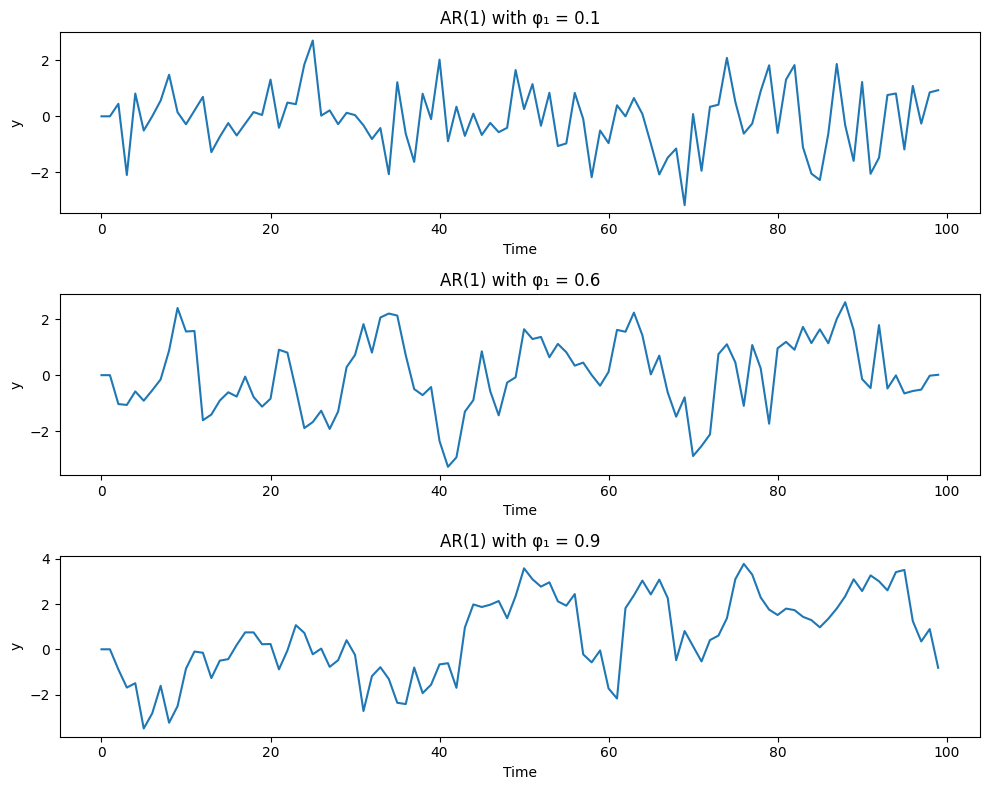

In [4]:
#Different values of phi_1
phi_values = [0.1, 0.6, 0.9]

fig, axes = plt.subplots(len(phi_values), 1, figsize=(10, 8))

for ax, phi1 in zip(axes, phi_values):
    y_ar = np.zeros(100)
    e = np.random.normal(0, 1, 100)

    for i in range(2, 100):
        y_ar[i] = phi1 * y_ar[i-1] + e[i]

    ax.plot(y_ar)
    ax.set_title(f"AR(1) with φ₁ = {phi1}")
    ax.set_xlabel("Time")
    ax.set_ylabel("y")

plt.tight_layout()
plt.show()

**c.(basic)** Write your own code to generate data from an MA(1) model with $\theta_1=0.6$ and $\sigma_2=1$. Plot the results also.

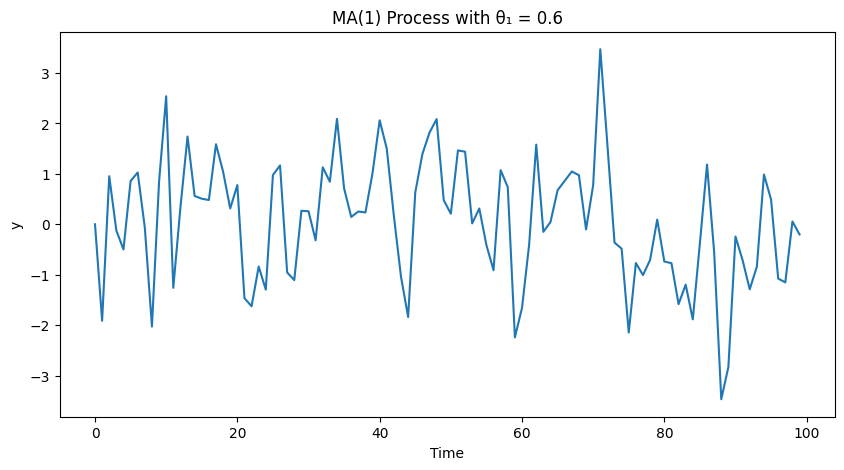

In [5]:
theta1 = 0.6
sigma = 1

# Generate errors
e = np.random.normal(0, sigma, 100)

# Generate MA(1) series
y_ma = np.zeros(100)

for i in range(1, 100):
    y_ma[i] = e[i] + theta1 * e[i-1]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(y_ma)
plt.xlabel("Time")
plt.ylabel("y")
plt.title("MA(1) Process with θ₁ = 0.6")
plt.show()

**d.(Regular)** Generate data from an ARMA(1,1) model with $\phi_1 = 0.6$ and $\theta_1=0.6$ and $\sigma_2=1$.


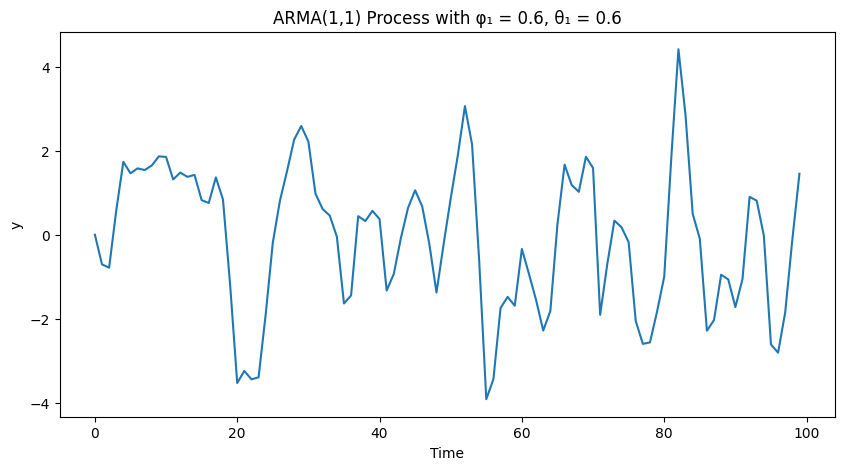

In [6]:
phi1 = 0.6
theta1 = 0.6
sigma = 1

# Generate errors
e = np.random.normal(0, sigma, 100)

# Generate ARMA(1,1) series
y_arma = np.zeros(100)

for i in range(1, 100):
    y_arma[i] = phi1 * y_arma[i-1] + e[i] + theta1 * e[i-1]

# Plot
plt.figure(figsize=(10, 5))
plt.plot(y_arma)
plt.xlabel("Time")
plt.ylabel("y")
plt.title("ARMA(1,1) Process with φ₁ = 0.6, θ₁ = 0.6")
plt.show()

**e.(Regular)** Generate data from an AR(2) model with $\phi_1=-0.8$, and $\phi_2=0.3$ and $\sigma_2=1$. (Note that these parameters will give a non-stationary series.)


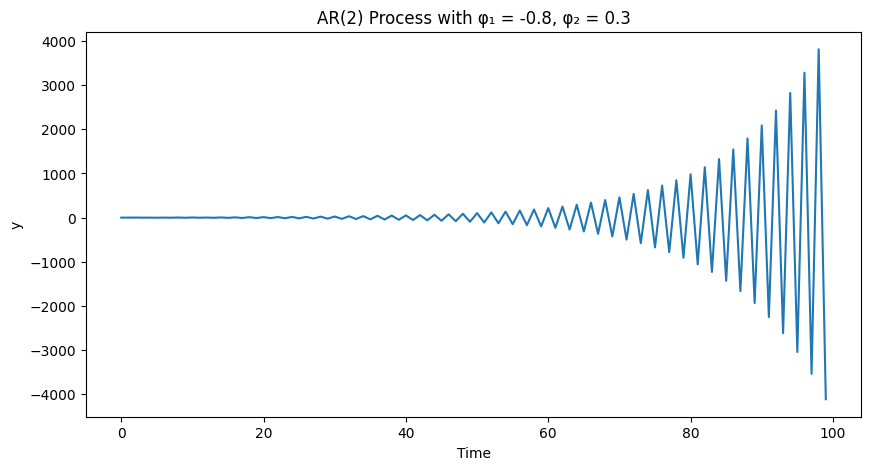

In [7]:
phi1 = -0.8
phi2 = 0.3
sigma = 1

e = np.random.normal(0, sigma, 100)

y_ar2 = np.zeros(100)

for i in range(2, 100):
    y_ar2[i] = phi1 * y_ar2[i-1] + phi2 * y_ar2[i-2] + e[i]

plt.figure(figsize=(10, 5))
plt.plot(y_ar2)
plt.xlabel("Time")
plt.ylabel("y")
plt.title("AR(2) Process with φ₁ = -0.8, φ₂ = 0.3")
plt.show()

**f.(Regular)**  Graph the latter two series and compare them.

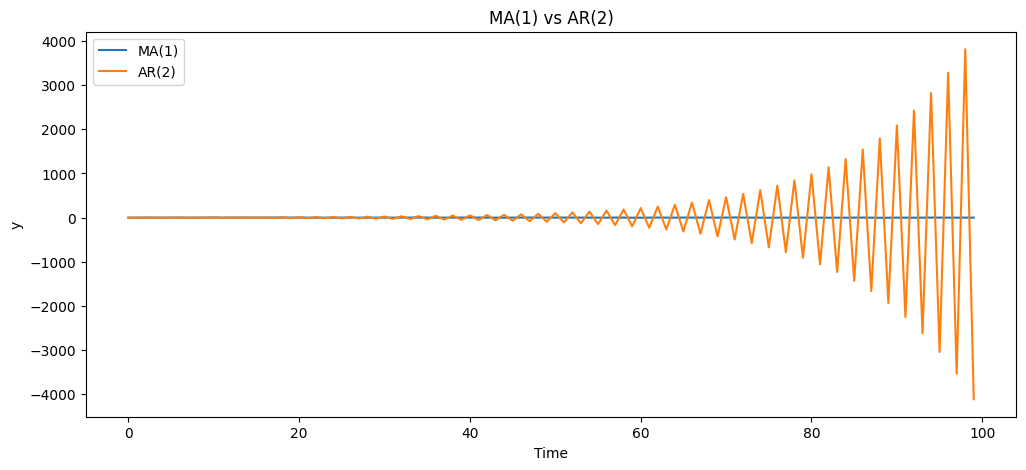

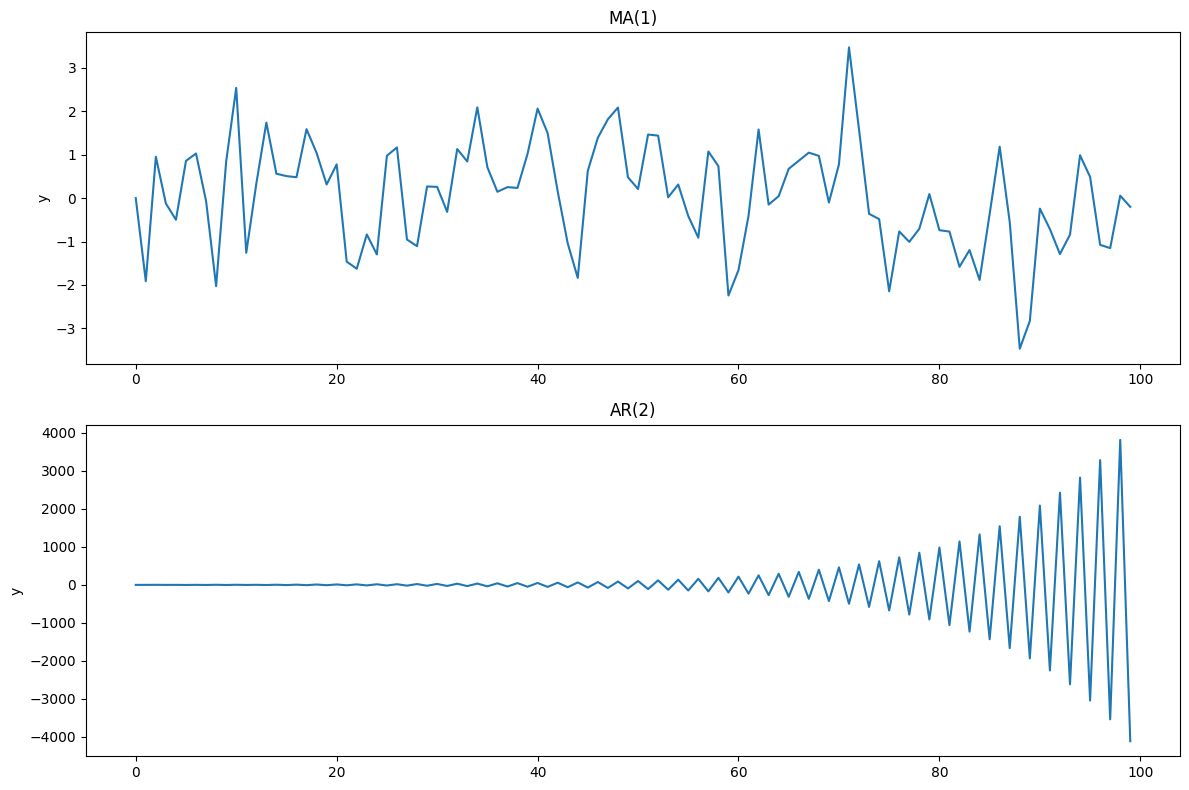

ARMA(1,1) std: 1.69667202219702
AR(2) std: 1099.083722646164


In [8]:
# Plot both
plt.figure(figsize=(12, 5))
plt.plot(y_ma, label="MA(1)")
plt.plot(y_ar2, label="AR(2)")
plt.xlabel("Time")
plt.ylabel("y")
plt.title("MA(1) vs AR(2)")
plt.legend()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(y_ma)
axes[0].set_title("MA(1)")
axes[0].set_ylabel("y")

axes[1].plot(y_ar2)
axes[1].set_title("AR(2)")
axes[1].set_ylabel("y")

plt.tight_layout()
plt.show()

print("ARMA(1,1) std:", y_arma.std())
print("AR(2) std:", y_ar2.std())

**g.(Regular)** How can you verify that the series in $e$ is indeed non-stationary?

In [9]:
phi1 = -0.8
phi2 = 0.3

roots = np.roots([-phi2, -phi1, 1])
print(roots)
print(np.abs(roots))

[ 3.59410999 -0.92744333]
[3.59410999 0.92744333]


We can verify that the series is non-stationary by calculating the roots of the AR characteristic equation. The roots are 3.5941 and −0.9274. Since one root has an absolute value smaller than 1, the stationarity condition is violated, and therefore the AR(2) is non-stationary.

## Exercise 2

Consider usmelec, the total net generation of electricity (in billion kilowatt hours) by the U.S. electric industry (monthly for the period January 1973 – June 2013). In general there are two peaks per year: in mid-summer and mid-winter.

The exercise is taken from the book https://otexts.com/fpp2/arima-exercises.html. You are encouraged to read the corresponding chapter to prepare for the examination.


In [10]:
# Read data
usmelec_data = pd.read_csv('usmelec.csv')
usmelec_data.head()# Inspect first few values.

,index,value
0,1973 Jan,160.218
1,1973 Feb,143.539
2,1973 Mar,148.158
3,1973 Apr,139.589
4,1973 May,147.395


Note that index is just the column header. For later convinience we change the date format to yyyy-mm-dd. And since it is a time series let us set its index as the date.

In [11]:
usmelec_data['index'] = pd.to_datetime(usmelec_data['index']) #change format to datetime
usmelec_data.set_index('index',inplace=True)# setting index.
usmelec_data.head()

C:\Users\luis\AppData\Local\Temp\ipykernel_12728\3167469212.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  usmelec_data['index'] = pd.to_datetime(usmelec_data['index']) #change format to datetime


,value
index,
1973-01-01,160.218
1973-02-01,143.539
1973-03-01,148.158
1973-04-01,139.589
1973-05-01,147.395


**a. (Basic)** Create line plot for the above time series. Do you observe a trend or seasonality in this plot?

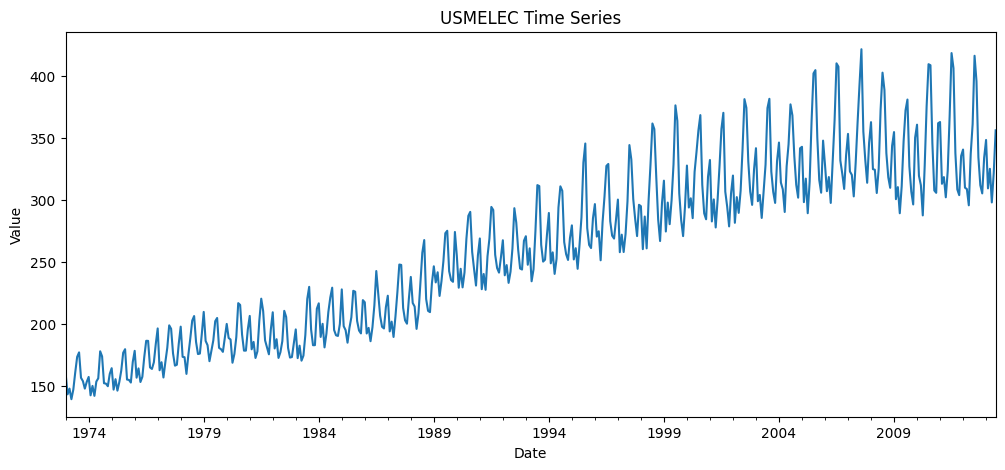

In [12]:
usmelec_data['value'].plot(figsize=(12, 5))
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('USMELEC Time Series')
plt.show()

Yes, there is a clear seasonality in the plot, with value spikes occuring in almost constant time distances between each other.

**b.(Basic)** Read the documentation about creating [KDE](https://en.wikipedia.org/wiki/Kernel_density_estimation) plot  [here](https://seaborn.pydata.org/generated/seaborn.kdeplot.html). Create density plot for your time series.

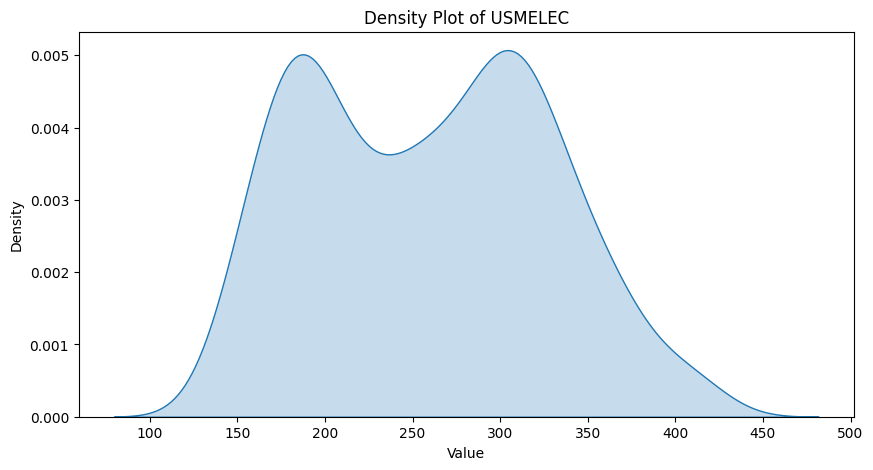

In [13]:
plt.figure(figsize=(10, 5))

sns.kdeplot(usmelec_data['value'], fill=True)

plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Density Plot of USMELEC')
plt.show()

 **c.(Basic)**	Create Box plot and violin plot for monthly generation. What seasonal pattern you can deduce from these plots.

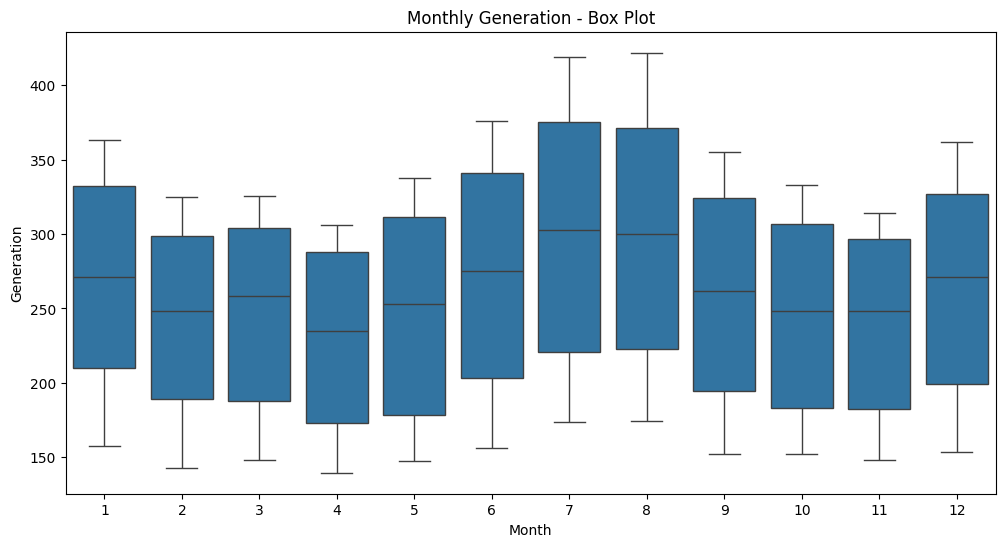

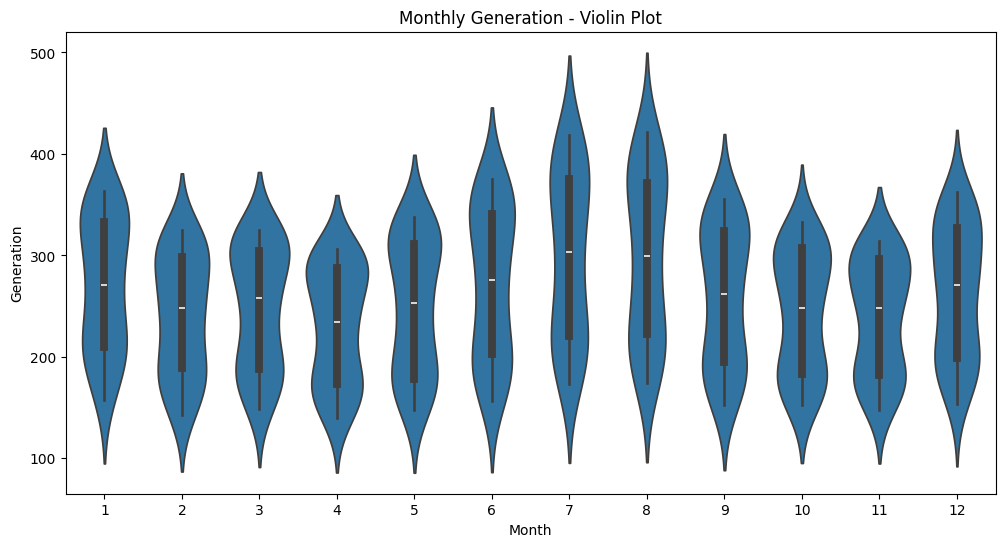

In [28]:
usmelec_data['month'] = usmelec_data.index.month

plt.figure(figsize=(12, 6))
sns.boxplot(data=usmelec_data, x='month', y='value')
plt.xlabel('Month')
plt.ylabel('Generation')
plt.title('Monthly Generation - Box Plot')
plt.show()

plt.figure(figsize=(12, 6))
sns.violinplot(data=usmelec_data, x='month', y='value')
plt.xlabel('Month')
plt.ylabel('Generation')
plt.title('Monthly Generation - Violin Plot')
plt.show()

As expected, 4 months have an increased value compared to the rest: December-January (winter), July-August (Summer). Through the violin plot we can also deduce that there was a period of fast increase on the generation, since all the months have two peaks (lower and higher parts), then the values closer to the middle were quickly substituted by higher values in the next years.

**d.(Basic)** Create [PACF](https://www.statsmodels.org/dev/generated/statsmodels.tsa.stattools.pacf.html?highlight=pacf)

What you can conclude from this visulization.

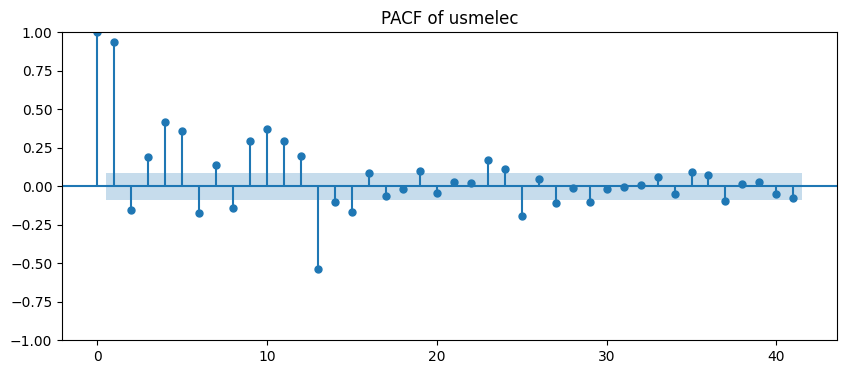

In [44]:
from statsmodels.graphics.tsaplots import plot_pacf

fig, ax = plt.subplots(figsize=(10, 4))
plot_pacf(usmelec_data['value'], lags=41, ax=ax, method='ywm')
plt.title("PACF of usmelec")
plt.show()

The PACF shows strong autocorrelation, especially at lag 1. Significant spikes also occur at lags 2–13, with a strong negative spike around lag 13. Further significant patterns around lags 23–25 are also present, with lag 25 showing a strong negative spike.
The repeated structure around lags 12 and 24 suggests annual seasonality, since the data are monthly and these lags correspond to one and two years, respectively. The negative spikes at lags 13 and 25 may reflect the underlying autocorrelation structure rather than a separate seasonal effect at those specific lags.

**e.(Basic)**	Examine the 12-month moving average and variance of this series to see what kind of trend is involved.

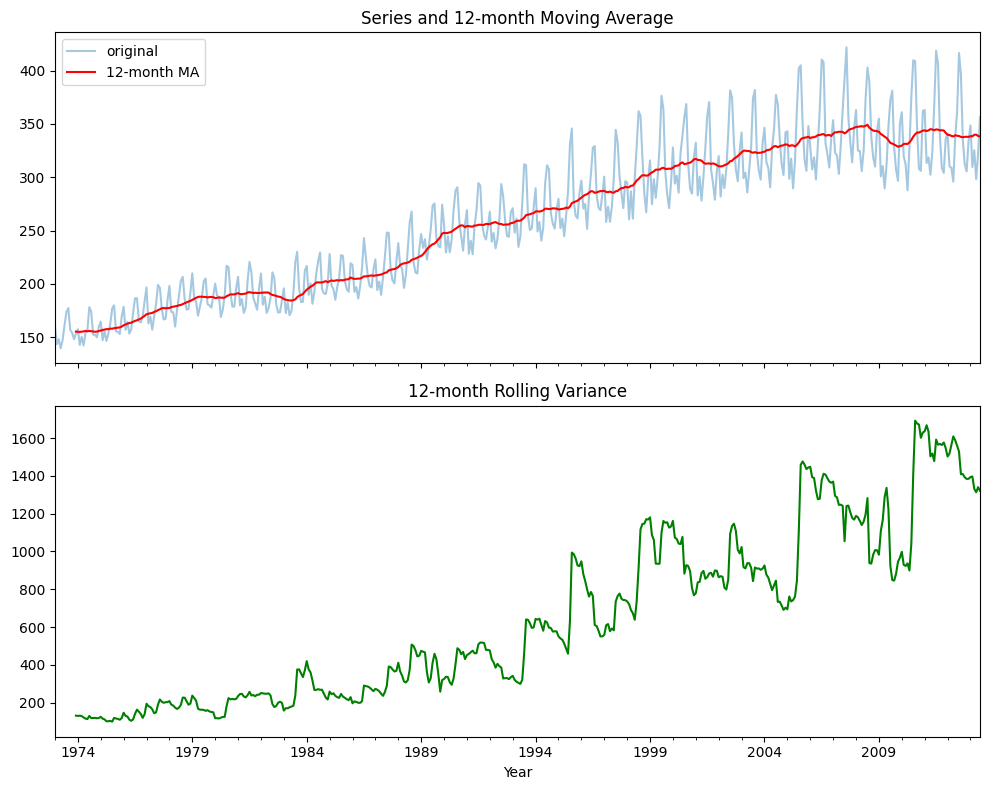

In [77]:
usmelec_data['ma12'] = usmelec_data['value'].rolling(window=12).mean()
usmelec_data['var12'] = usmelec_data['value'].rolling(window=12).var()

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

usmelec_data['value'].plot(ax=axes[0], alpha=0.4, label='original')
usmelec_data['ma12'].plot(ax=axes[0], color='red', label='12-month MA')
axes[0].set_title("Series and 12-month Moving Average")
axes[0].legend()

usmelec_data['var12'].plot(ax=axes[1], color='green')
axes[1].set_title("12-month Rolling Variance")
axes[1].set_xlabel("Year")

plt.tight_layout()
plt.show()

**f.(Regular)**  Substantiate here breifly why your choosen transformation is appropriate?

Since the dataset contains monthly observations with yearly seasonality, using a 12-month window allows us to analyse the moving average and variance over one complete seasonal cycle.

**g.(Regular)**	Are the data stationary? If not, find an appropriate differencing which yields stationary data. Most time second order differencing is sufficient.

Substantiate that your choosen difference is appropriate?

**Hint:** [Augmented Dickey–Fuller](https://www.statsmodels.org/dev/generated/statsmodels.tsa.stattools.adfuller.html) test can be used to test stationarity.

If you need code add a code block yourself.

In [83]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(usmelec_data['value'].dropna())

print("ADF statistic:", result[0])
print("p-value:", result[1])

usmelec_data['diff1'] = usmelec_data['value'].diff()

result = adfuller(usmelec_data['diff1'].dropna())

print("First-order difference:")
print("ADF statistic:", result[0])
print("p-value:", result[1])

ADF statistic: -1.412569851067804
p-value: 0.5762353593662202
First-order difference:
ADF statistic: -5.663434672382557
p-value: 9.267094557637553e-07


C:\Users\luis\AppData\Local\Temp\ipykernel_41116\1826841311.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(usmelec_data['value'].dropna())
C:\Users\luis\AppData\Local\Temp\ipykernel_41116\1826841311.py:10: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(usmelec_data['diff1'].dropna())


The series is not stationary, as indicated by the ADF test (p-value > 0.05). After applying first-order differencing, the series becomes stationary (p-value < 0.05). Therefore, first-order differencing is appropriate (d = 1).

**h.(Basic)**	Identify a couple of ARIMA models that might be useful in describing the time series. Which of your models is the best according to their AIC values?
Hint: You can create different ARIMA models using different values of $p$ and $q$. You can either choose these values randomly(not a vey good idea) or using ACF/PACF or apply grid search.

In [37]:
from statsmodels.tsa.arima.model import ARIMA

usmelec_data = usmelec_data.asfreq('MS')
models = {
    'ARIMA(1,1,0)': ARIMA(usmelec_data['value'], order=(1,1,0)),
    'ARIMA(0,1,1)': ARIMA(usmelec_data['value'], order=(0,1,1)),
    'ARIMA(1,1,1)': ARIMA(usmelec_data['value'], order=(1,1,1)),
    'ARIMA(2,1,0)': ARIMA(usmelec_data['value'], order=(2,1,0)),
    'ARIMA(0,1,2)': ARIMA(usmelec_data['value'], order=(0,1,2)),
    'ARIMA(2,1,1)': ARIMA(usmelec_data['value'], order=(2,1,1)),
    'ARIMA(2,1,2)': ARIMA(usmelec_data['value'], order=(2,1,2)),
    'ARIMA(3,1,1)': ARIMA(usmelec_data['value'], order=(3,1,1)),
    'ARIMA(1,1,3)': ARIMA(usmelec_data['value'], order=(1,1,3)),
    'ARIMA(3,1,3)': ARIMA(usmelec_data['value'], order=(3,1,3)),
}

for name, model in models.items():
    fitted = model.fit()
    print(f"{name}: AIC = {fitted.aic}")

ARIMA(1,1,0): AIC = 4450.1081204824
ARIMA(0,1,1): AIC = 4446.524825127881
ARIMA(1,1,1): AIC = 4443.364254618831
ARIMA(2,1,0): AIC = 4424.442927814911
ARIMA(0,1,2): AIC = 4329.5371805376035


C:\Users\luis\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
C:\Users\luis\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params
C:\Users\luis\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
C:\Users\luis\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start

ARIMA(2,1,1): AIC = 4253.964378155575
ARIMA(2,1,2): AIC = 4131.178347191022
ARIMA(3,1,1): AIC = 4218.125611828298
ARIMA(1,1,3): AIC = 4268.336961655865
ARIMA(3,1,3): AIC = 4229.847081457415


C:\Users\luis\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


Based on the AIC values, ARIMA(2,1,2) is the best model among those tested, as it has the lowest AIC of 4131.178.

**i.(Regular)** Estimate the parameters of your best model and do diagnostic testing on the **residuals** (mind the difference between residual and error). Do the residuals resemble white noise? If not, try to find another ARIMA model which fits better.

Hint: Look for Ljung-Box Test and also  Shapiro-Wilk test for normality.

In [38]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import shapiro

results = []

for name, model in models.items():
    try:
        # Fit model
        fitted = model.fit()
        residuals = fitted.resid.dropna()

        # Ljung-Box test
        lb = acorr_ljungbox(
            residuals,
            lags=[12, 24],
            return_df=True
        )

        # Shapiro-Wilk test
        shapiro_stat, shapiro_p = shapiro(residuals)

        results.append({
            'Model': name,
            'AIC': fitted.aic,
            'LB p-value (12)': lb.loc[12, 'lb_pvalue'],
            'LB p-value (24)': lb.loc[24, 'lb_pvalue'],
            'Shapiro p-value': shapiro_p
        })

    except Exception as e:
        results.append({
            'Model': name,
            'AIC': None,
            'LB p-value (12)': None,
            'LB p-value (24)': None,
            'Shapiro p-value': None
        })
        print(f"{name} failed: {e}")

results_df = pd.DataFrame(results)

# Sort by AIC
results_df = results_df.sort_values('AIC')

results_df

C:\Users\luis\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
C:\Users\luis\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params
C:\Users\luis\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
C:\Users\luis\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start

,Model,AIC,LB p-value (12),LB p-value (24),Shapiro p-value
6,"ARIMA(2,1,2)",4131.178347,2.076134e-78,1.620401e-148,2.156423e-15
7,"ARIMA(3,1,1)",4218.125612,1.799206e-66,1.235892e-129,1.613477e-14
9,"ARIMA(3,1,3)",4229.847081,3.826192e-78,2.409052e-151,4.939407e-13
5,"ARIMA(2,1,1)",4253.964378,1.424596e-86,6.243286e-166,1.268782e-12
8,"ARIMA(1,1,3)",4268.336962,3.444295e-79,6.387344e-154,1.649319e-11
4,"ARIMA(0,1,2)",4329.537181,1.726840e-104,3.961271e-202,2.018308e-11
3,"ARIMA(2,1,0)",4424.442928,1.342577e-121,2.203221e-234,6.872618e-09
2,"ARIMA(1,1,1)",4443.364255,4.645885e-136,4.124972e-264,1.103222e-07
1,"ARIMA(0,1,1)",4446.524825,5.219546e-135,2.372706e-262,4.275365e-09
0,"ARIMA(1,1,0)",4450.108120,1.000355e-141,7.177455e-276,3.561535e-09


The tested ARIMA models failed to produce white-noise residuals. Increasing the AR and MA orders did not remove the significant residual autocorrelation, suggesting that the remaining dependence is not adequately captured by the non-seasonal ARIMA structure.

**j.(Regular)**	Forecast the next 15 years of electricity generation by the U.S. electric industry. Get the latest figures from the [EIA](https://www.eia.gov/totalenergy/data/monthly/#electricity) to check the accuracy of your forecasts.

              Forecast    Lower CI    Upper CI
2013-07-01  380.930965  348.025705  413.836225
2013-08-01  365.813628  318.207685  413.419572
2013-09-01  326.220790  266.670572  385.771009
2013-10-01  301.833856  232.428936  371.238777
2013-11-01  317.072682  239.721344  394.424019
...                ...         ...         ...
2028-02-01  357.442408  -97.502017  812.386833
2028-03-01  320.022644 -136.327998  776.373286
2028-04-01  304.016506 -153.700995  761.734007
2028-05-01  325.443573 -133.522169  784.409314
2028-06-01  362.811567  -97.321927  822.945061

[180 rows x 3 columns]


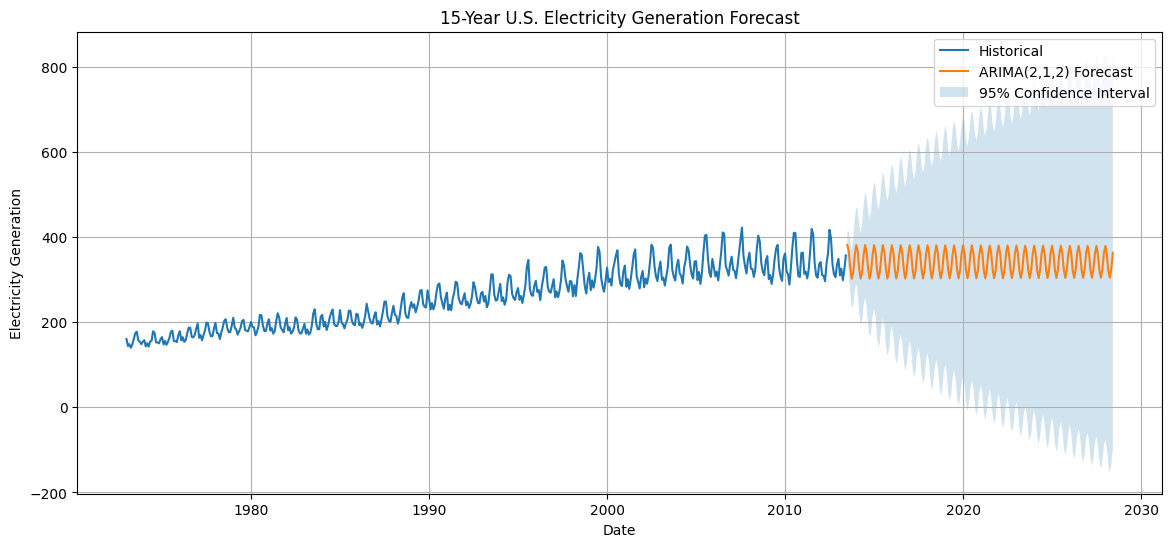

In [41]:
model = ARIMA(usmelec_data['value'], order=(2,1,2))
model_fit = model.fit()

# Forecast 15 years = 180 months
forecast_steps = 15 * 12

forecast = model_fit.get_forecast(steps=forecast_steps)

forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# Create forecast dates
forecast_dates = pd.date_range(
    start=usmelec_data.index[-1] + pd.offsets.MonthBegin(1),
    periods=forecast_steps,
    freq='MS'
)

forecast_mean.index = forecast_dates
forecast_ci.index = forecast_dates

# Display forecast
forecast_df = pd.DataFrame({
    'Forecast': forecast_mean,
    'Lower CI': forecast_ci.iloc[:, 0],
    'Upper CI': forecast_ci.iloc[:, 1]
})

print(forecast_df)

plt.figure(figsize=(14, 6))

plt.plot(
    usmelec_data.index,
    usmelec_data['value'],
    label='Historical'
)

plt.plot(
    forecast_df.index,
    forecast_df['Forecast'],
    label='ARIMA(2,1,2) Forecast'
)

plt.fill_between(
    forecast_df.index,
    forecast_df['Lower CI'],
    forecast_df['Upper CI'],
    alpha=0.2,
    label='95% Confidence Interval'
)

plt.xlabel('Date')
plt.ylabel('Electricity Generation')
plt.title('15-Year U.S. Electricity Generation Forecast')
plt.legend()
plt.grid(True)
plt.show()

Even without checking the EIA, it's possible to see that the model was insufficient. Since ARIMA models aren't capable of forecasting seasonality, the results are simple waves, folowing the general pattern of December/January been higher than the rest.

**k.(Regular)**	Eventually, the prediction intervals are so wide that the forecasts are not particularly useful. How many years of forecasts do you think are sufficiently accurate to be usable?

2013-01-01     47.623176
2014-01-01     92.519796
2015-01-01    130.502122
2016-01-01    159.503969
2017-01-01    183.950154
2018-01-01    205.494399
2019-01-01    224.978375
2020-01-01    242.900925
2021-01-01    259.586859
2022-01-01    275.261780
2023-01-01    290.089980
2024-01-01    304.195525
2025-01-01    317.674831
2026-01-01    330.604597
2027-01-01    343.047033
2028-01-01    352.102811
Freq: YS-JAN, Name: Width (%), dtype: float64


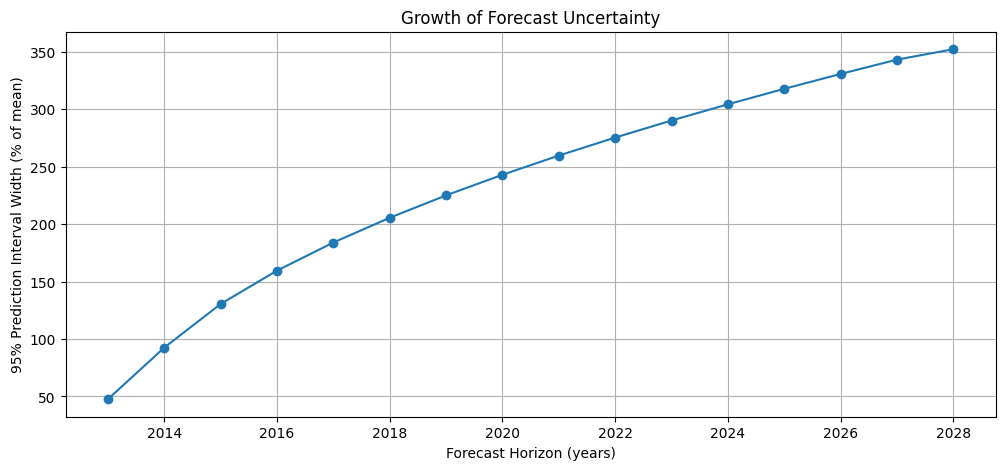

In [43]:
# Width of the 95% prediction interval
forecast_df['Interval Width'] = (
    forecast_df['Upper CI'] - forecast_df['Lower CI']
)

# Average historical value
mean_value = usmelec_data['value'].mean()

# Interval width as percentage of the historical mean
forecast_df['Width (%)'] = (
    forecast_df['Interval Width'] / mean_value * 100
)

# Look at the first 15 years, averaged by year
yearly_width = forecast_df['Width (%)'].resample('YS').mean()

print(yearly_width)

plt.figure(figsize=(12, 5))

plt.plot(yearly_width.index.year, yearly_width.values, marker='o')

plt.xlabel('Forecast Horizon (years)')
plt.ylabel('95% Prediction Interval Width (% of mean)')
plt.title('Growth of Forecast Uncertainty')
plt.grid(True)
plt.show()

The prediction intervals become very wide very quickly. The average width of the 95% prediction interval is approximately 47.6% of the historical mean after one year and increases to 92.5% after two years. By the third year, the interval width is already approximately 130.5% of the historical mean.

Therefore, I would consider approximately **one year of forecasts** to be the maximum reasonable usable horizon for this model. Even at this horizon, the uncertainty is substantial, while forecasts beyond two years have prediction intervals so wide that they provide little useful quantitative information. This further demonstrates the limitations of using the non-seasonal ARIMA(3,1,3) model for long-term electricity-generation forecasting.

## Exercise 3
Read about simple exponential smoothing in the chapter [Simple exponential smoothing](https://otexts.com/fpp3/ses.html) (FPP3, Section 8.1) and watch the associated recorded video. Then complete the following exercises in Python using the annual flow of the river Nile (1871–1970), which is included in `statsmodels`:

```python
import pandas as pd
import statsmodels.api as sm

nile = sm.datasets.nile.load_pandas().data
y = nile["volume"]
y.index = pd.PeriodIndex(nile["year"].astype(int), freq="Y")
```
**a.(Regular)** Plot the series. Explain why simple exponential smoothing is an appropriate method for this series (think about trend and seasonality).

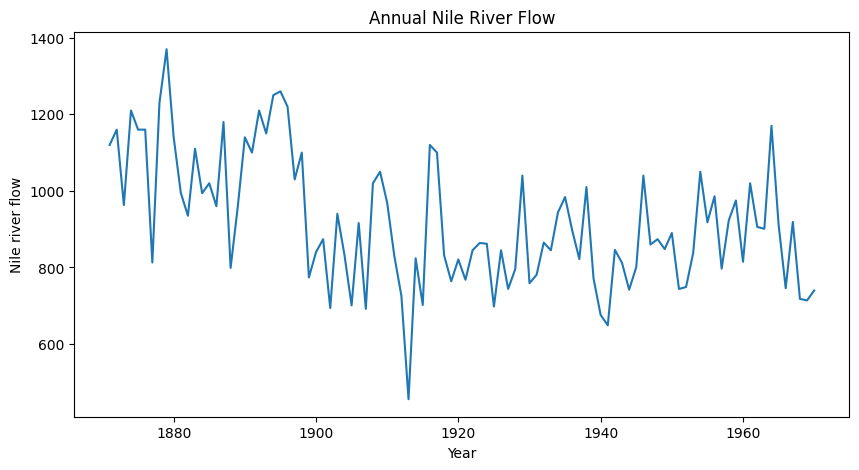

In [47]:
#Implementation Hyndman-Khandakar algorithm
nile = sm.datasets.nile.load_pandas().data
y = nile["volume"]
y.index = pd.PeriodIndex(nile["year"].astype(int), freq="Y")

plt.figure(figsize=(10, 5))
plt.plot(y.index.to_timestamp(), y.values)

plt.xlabel("Year")
plt.ylabel("Nile river flow")
plt.title("Annual Nile River Flow")
plt.show()

As the plot shows, there is no visible seasonality in the series. The data fluctuates considerably from year to year, with a decreasing trend before 1900 that is no longer apparent afterwards. Overall, the observations fluctuate around a relatively stable mean level of approximately 900.

Therefore, the series has no seasonality, no strong persistent trend, and a relatively stable level. These are the characteristics for which Simple Exponential Smoothing is an appropriate forecasting method.

**b.(Advanced)** Write your own function `ses_forecast(y, alpha, level)` that implements simple exponential smoothing. The arguments are `y` (the time series as a NumPy array or pandas Series), `alpha` (the smoothing parameter $\alpha$) and `level` (the initial level $\ell_0$). The function should return the one-step-ahead forecast of the next observation in the series, i.e. $\hat{y}_{T+1|T}$.

Compare your result with `statsmodels`: fit `SimpleExpSmoothing` from `statsmodels.tsa.holtwinters` with the **same** fixed $\alpha$ and $\ell_0$ (use `smoothing_level=alpha`, `initial_level=level` and `optimized=False` in `.fit()`), then call `.forecast(1)`. Does your function give the same forecast?


In [50]:
def ses_forecast(y, alpha, level):
    y = np.asarray(y)

    for value in y:
        level = alpha * value + (1 - alpha) * level

    return level

In [52]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

alpha = 0.5
level = y.iloc[0]

my_forecast = ses_forecast(y, alpha, level)

# Statsmodels
model = SimpleExpSmoothing(
    y,
    # Initial level known
    initialization_method="known",
    initial_level=level
)

fit = model.fit(
    smoothing_level=alpha,
    optimized=False
)

sm_forecast = fit.forecast(1).iloc[0]

print("My forecast:        ", my_forecast)
print("Statsmodels forecast:", sm_forecast)
print("Same:", np.isclose(my_forecast, sm_forecast))

My forecast:         749.5313635046833
Statsmodels forecast: 749.5313635046833
Same: True


**c. (Advanced)** Modify your function from the previous exercise so that it returns the sum of squared one-step errors (SSE) rather than the forecast of the next observation, i.e. `ses_sse(params, y)` where `params = [alpha, level]`.

Then use `scipy.optimize.minimize` to find the values of $\alpha$ and $\ell_0$ that minimise the SSE.

Compare your estimates with the ones `statsmodels` produces when you let it optimise the parameters itself:

```python
fit = SimpleExpSmoothing(y, initialization_method="estimated").fit()
fit.params["smoothing_level"], fit.params["initial_level"]
```

Do you get the same values? If they differ slightly, explain why (hint: different optimisers, starting values and parameter bounds).


In [53]:
def ses_sse(params, y):
    alpha, level = params
    sse = 0.0
    
    for value in y:
        forecast = level
        
        error = value - forecast
        sse += error**2
        
        level = alpha * value + (1 - alpha) * level
    
    return sse

In [54]:
from scipy.optimize import minimize

y_array = y.to_numpy()

# Initial guesses: [alpha, level]
initial_params = [0.5, y_array[0]]

result = minimize(
    ses_sse,
    initial_params,
    args=(y_array,),
    bounds=[(0, 1), (None, None)]
)

alpha_opt, level_opt = result.x

print("Optimized alpha:", alpha_opt)
print("Optimized level:", level_opt)
print("SSE:", result.fun)

Optimized alpha: 0.2457314194363505
Optimized level: 1110.7569563543314
SSE: 2038674.4322478566


In [59]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

fit = SimpleExpSmoothing(
    y,
    initialization_method="estimated"
).fit()

print("Statsmodels alpha:", fit.params["smoothing_level"])
print("Statsmodels level:", fit.params["initial_level"])

print("\nComparison")
print("-----------------------------")
print(f"My alpha:          {alpha_opt:.8f}")
print(f"Statsmodels alpha: {fit.params['smoothing_level']:.8f}")
print()
print(f"My level:          {level_opt:.8f}")
print(f"Statsmodels level: {fit.params['initial_level']:.8f}")

Statsmodels alpha: 0.24572761639063853
Statsmodels level: 1110.741360119633

Comparison
-----------------------------
My alpha:          0.24573142
Statsmodels alpha: 0.24572762

My level:          1110.75695635
Statsmodels level: 1110.74136012


The resulting estimates are very close to those obtained with statsmodels. Small differences may occur because the two implementations can use different optimization algorithms, starting values, convergence criteria, and parameter bounds. Therefore, slightly different parameter estimates are expected even though both methods are minimizing the same SSE objective.

**d. (Advanced)** Combine your previous two functions into a single function `ses(y)` that both finds the optimal values of $\alpha$ and $\ell_0$ **and** returns the forecast of the next observation in the series. Check that its output matches `.forecast(1)` from the optimised `statsmodels` model.

In [63]:
def ses(y):
    y = np.asarray(y)

    # Optimize alpha and initial level
    result = minimize(
        ses_sse,
        [0.5, y[0]],       # initial guesses
        args=(y,),
        bounds=[(0, 1), (None, None)]
    )

    alpha, level = result.x

    # Calculate the final level
    for value in y:
        level = alpha * value + (1 - alpha) * level

    return level

In [64]:
my_forecast = ses(y)

# Statsmodels
fit = SimpleExpSmoothing(
    y,
    initialization_method="estimated"
).fit()

sm_forecast = fit.forecast(1).iloc[0]

print("Our forecast:        ", my_forecast)
print("Statsmodels forecast:", sm_forecast)
print("Same:", np.isclose(my_forecast, sm_forecast))

Our forecast:         805.3151562183392
Statsmodels forecast: 805.316428891047
Same: True
